hs_get_scores 는 예측모형용 성능 평가

이진분류용 함수..cls_bin

다항분류는 혼동행렬 기반 계산 불가x ....


파이프라인 쓸떄와 차이를 두려고...

scoring none, rmse 일떄는 예측, auc로 해야하니깡....



shap 기능의 하위기능으로 LinearExplainer 라는 선형용 트리가 있는데
이걸 사용해서 로지스틱 회귀 평가할거야
앞으로는 다른 선형회귀 분석도...이거로...

로지스틱에선 오즈비



# [LAB 09] 지도학습 > 분류 > 03-로지스틱 | 성능평가함수개선

## #01.준비작업
### [1] 패키지 가져오기

In [1]:
from hossam import *

import pandas as pd
from pandas import merge
from pandas import Series, DataFrame,concat
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from itertools import product
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

#로지스틱 회귀 모형
from sklearn.linear_model import LogisticRegression

#로지스틱 성능 평가 함수
from sklearn.metrics import (
      log_loss,
      accuracy_score,
      confusion_matrix,
      roc_auc_score,
      roc_curve,accuracy_score,
      recall_score,
      precision_score,
      f1_score)



### [2] 데이터 가져오기
- 결측치 정제 및 로그변환을 완료한 데이터

In [2]:
origin = load_data('pima_indians_diabetes_preprocessed')
origin.head()

캐글에서 제공하는 pima_indians_diabetes의 전처리 완료 버전(결측치 정제+로그변환) (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.946,5.004,72,3.584,4.836,3.544,0.487,3.932,1
1,0.693,4.454,66,3.401,4.836,3.318,0.301,3.466,0
2,2.197,5.215,64,3.401,4.836,3.190,0.514,3.497,1
3,0.693,4.500,66,3.178,4.554,3.371,0.154,3.091,0
4,0.000,4.927,40,3.584,5.130,3.786,1.190,3.526,1


### [3] 훈련,검증 데이터 분리

In [3]:
df = origin

# 종속변수는 정수형으로 변환해야 한다.
df['Outcome'] = df['Outcome'].astype('int')

yname = "Outcome"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((614, 8), (154, 8), (614,), (154,))

## #02.로지스틱 모형 적합

In [4]:
%%time

pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=52))
])

param_grid = {
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gs.fit(x_train, y_train)

estimator = gs.best_estimator_
estimator


CPU times: total: 234 ms
Wall time: 6.64 s


Pipeline(steps=[('VIF_Selector', VIFSelector()), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced',
                                    random_state=52))])

## #03.성능평가
### [1] 성능평가 함수
- 이진 분류

In [5]:
def hs_cls_bin_scores(estimator, x_test, y_test):

    # 피_양성 확률
    y_pred_proba = estimator.predict_proba(x_test)

    # 1로 분류될 확률
    y_pred_proba_1 = estimator.predict_proba(x_test)[:, 1]

    # 예측값
    y_pred = estimator.predict(x_test)

    # 의사결정계수 (Pseudo R²)
    log_loss_test = -log_loss(y_test, y_pred_proba, normalize=False)
    y_null = np.ones_like(y_test) * y_test.mean()
    log_loss_null = -log_loss(y_test, y_null, normalize=False)
    pseudo_r2 = 1 - (log_loss_test / log_loss_null)

    # 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    ((TN, FP), (FN, TP)) = cm

    # 클래스 이름
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # auc score
    auc = roc_auc_score(y_test, y_pred_proba_1)

    score_df = DataFrame({
        "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
        "정밀도(Precision)": [precision_score(y_test, y_pred)],
        "재현율(Recall,tpr)": [recall_score(y_test, y_pred)],
        "위양성률(Fallout,fpr)": [FP / (TN + FP)],
        "특이성(TNR)": [1 - (FP / (TN + FP))],
        "F1-Score": [f1_score(y_test, y_pred)],
        "AUC": [auc]
    }, index=[classname])

    # ------------------------------
    # ROC 곡선 그리기
    # ------------------------------

    roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba_1)

    # 1) 그래프 초기화
    my_dpi = 100  # 그래프 해상도

    width_px = 1000   # 그래프 가로 크기
    height_px = 900   # 그래프 세로 크기
    rows = 1          # 그래프 행 수
    cols = 1          # 그래프 열 수

    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    # 2) LinePlot 그리기
    sb.lineplot(x=roc_fpr, y=roc_tpr)
    sb.lineplot(x=[0, 1], y=[0, 1], color='red', linestyle=":", alpha=0.5)
    plt.fill_between(x=roc_fpr, y1=roc_tpr, alpha=0.1)

    # 3) 그래프 꾸미기
    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC={auc:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # 4) 출력
    plt.tight_layout()
    plt.show()
    plt.close()

    return score_df


#### 함수 확인

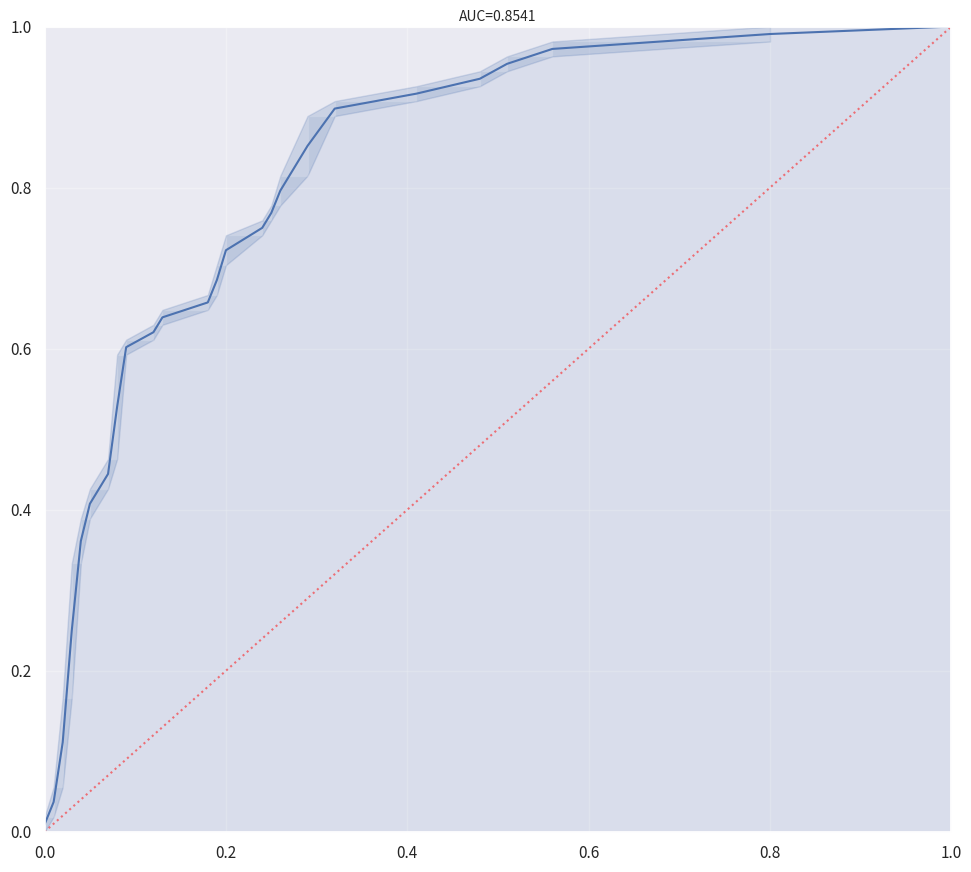

,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
LogisticRegression,0.766,0.629,0.815,0.260,0.740,0.710,0.854


In [6]:
hs_cls_bin_scores(estimator,x_test,y_test)

### [2] 과적합판정
#### 함수개선

In [7]:
def hs_learning_cv(
    estimator,
    x,
    y,
    scoring=None,  # <-- None 으로 기본값 수정
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    # =====================================================
    # [NEW] 문제 유형 자동 판별
    # =====================================================
    is_classification = (
        hasattr(estimator, "_estimator_type")
        and estimator._estimator_type == "classifier"
    )

    # =====================================================
    # [NEW] scoring 자동 설정
    # =====================================================
    if scoring is None:
        scoring = "roc_auc" if is_classification else "neg_root_mean_squared_error"

    # =====================================================
    # learning_curve 계산
    # =====================================================
    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=False,
        random_state=52,
    )

    # =====================================================
    # 모델명 추출 (Pipeline 대응)
    # =====================================================
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # =====================================================
    # 회귀 전용 처리
    # =====================================================
    if not is_classification:

        # neg RMSE → RMSE
        train_rmse = -train_scores
        cv_rmse = -cv_scores

        train_mean = train_rmse.mean(axis=1)
        cv_mean = cv_rmse.mean(axis=1)
        cv_std = cv_rmse.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train / final_cv
        var_ratio = final_std / final_cv

        # -------------------------------
        # 기준 RMSE 계산
        # -------------------------------
        y_mean = y.mean()
        rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

        std_y = y.std()

        min_r2 = 0.10
        rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

        some_threshold = min(rmse_naive, std_y, rmse_r2)

        train_slope = train_mean[-1] - train_mean[-2]
        cv_slope = cv_mean[-1] - cv_mean[-2]

        if gap_ratio >= 0.95 and final_cv > some_threshold:
            status = "⚠ 과소적합"
        elif gap_ratio <= 0.8 and train_slope > 0 and cv_slope < 0:
            status = "⚠ 데이터 추가시 일반화 기대"
        elif gap_ratio <= 0.8:
            status = "⚠ 과대적합"
        elif gap_ratio >= 0.95 and var_ratio <= 0.10:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.15:
            status = "⚠ 데이터 부족"
        else:
            status = "⚠ 판단유보"

        metric_name = "RMSE"

    # =====================================================
    # 분류 전용 처리
    # =====================================================
    else:

        train_metric = train_scores
        cv_metric = cv_scores

        train_mean = train_metric.mean(axis=1)
        cv_mean = cv_metric.mean(axis=1)
        cv_std = cv_metric.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train - final_cv
        var_ratio = final_std

        if final_train < 0.6 and final_cv < 0.6:
            status = "⚠ 과소적합"
        elif gap_ratio > 0.1:
            status = "⚠ 과대적합"
        elif gap_ratio <= 0.05 and var_ratio <= 0.05:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.1:
            status = "⚠ 데이터 부족"
        else:
            status = "⚠ 판단유보"

        metric_name = scoring.upper()

    # =====================================================
    # 결과 정리
    # =====================================================
    result_df = DataFrame(
        {
            f"Train {metric_name}": [final_train],
            f"CV {metric_name} 평균": [final_cv],
            f"CV {metric_name} 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # =====================================================
    # 학습곡선 시각화
    # =====================================================
    figsize = (1280 / my_dpi, 720 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"Train {metric_name}",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"CV {metric_name}",
    )

    ax.set_xlabel("학습 데이터 크기", fontsize=8, labelpad=5)
    ax.set_ylabel("성능", fontsize=8, labelpad=5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return result_df


#### 함수 확인

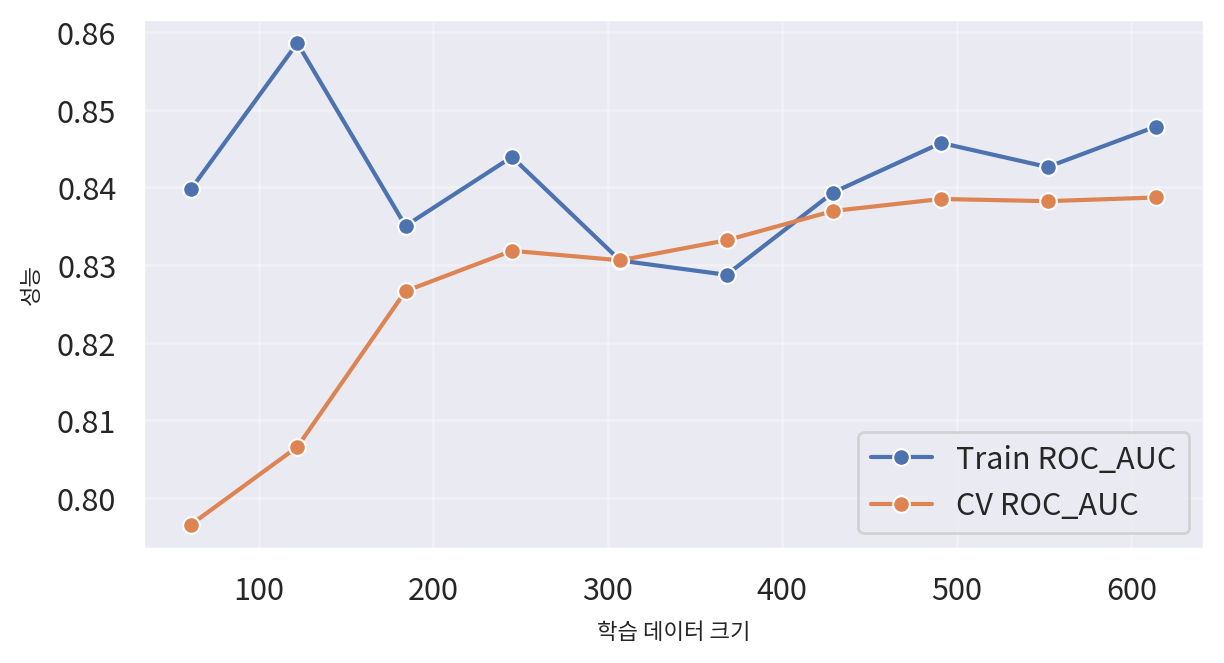

,Train ROC_AUC,CV ROC_AUC 평균,CV ROC_AUC 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
LogisticRegression,0.848,0.839,0.030,0.009,0.030,✅ 일반화 양호


In [8]:
hs_learning_cv(estimator,x,y)